In [6]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures  # For the Counter function
using Tar
using CodecZlib

In [7]:
rel_propn = 0.01
## vary these for different dispersal scenarios
gamma = 0.33    # dispersal rate from release site to household
rho = 0.33     # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

rel_fem = 5
rel_male = 5
delta_rel = 10

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relhhold"

"relhhold"

In [8]:
# Define parameters dictionary
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time

## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release

t_start = 0    
t_end = 6000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7) + 1   # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    #:rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 24 entries:
  :b       => 0.54
  :alpha   => 0.1
  :gamma   => 0.33
  :m_free0 => 0
  :rho     => 0.33
  :t_start => 0
  :h       => 0.756404
  :rel_t   => 150
  :male_w0 => 0
  :fem_m0  => 8
  :K       => 30
  :phi     => 0.85
  :fem_w0  => 0
  :d       => 0.12
  :k       => 0.3
  :v       => 1
  :u       => 1
  :male_m0 => 8
  :tau     => 0.33
  ⋮        => ⋮

In [9]:
### Convert dispersal parameters to a string and remove the decimal point
## We will use this to call the correct data files
rho_str = replace(string(rho), "." => "")
tau_str = replace(string(tau), "." => "")
gamma_str = replace(string(gamma), "." => "")
alpha_str = replace(string(alpha), "." => "")

"01"

Function to find job ID

In [10]:
# Read the CSV file into a DataFrame
JOBS_DF = CSV.read("reg_rel_single_hhold.csv", DataFrame)

# Function to find the JOB_ID for given rel_fem and rel_male
function find_job_id(df::DataFrame, rel_fem_value, rel_male_value, rel_time)
    found = false
    for row in eachrow(df)
        if !ismissing(row[Symbol("job no.")]) &&
           row[Symbol("no. females")] == rel_fem_value && row[Symbol("no. males")] == rel_male_value &&
           row[Symbol("release time step")] == rel_time
            return row[Symbol("job no.")]
            found = true
            break
        else
            continue
        end
    end # Return nothing if no matching row is found
    if !found
        return nothing
    end
end

find_job_id (generic function with 1 method)

In [11]:
# Extract the .tar.gz file
function extract_tar_gz(file_path::String, dest_dir::String)
    open(file_path) do io
        tar_io = GzipDecompressorStream(io)
        Tar.extract(tar_io, dest_dir)
    end
end

# Define the sex ratios and release time steps
sex_ratios = [(1,1), (3,1), (3,3), (3,5), (3,10), (5,1), (5,3), (5,5), (5,10), (10,3), (10,5), (10,10), (10,1)]
rel_time_steps = [10, 25, 50, 75, 100]#[150, 200, 250, 300, 350]

for r in sex_ratios
    for t in rel_time_steps
        fem, male = r
        JOB_ID = find_job_id(JOBS_DF, fem, male, t)
        println(fem, "  ", male, "  ", t, "  ", JOB_ID)
        # Define the file path
        file_path = "single_hhold_release\\sim_results_$(JOB_ID).tar.gz" #testing_gen_hhold_release\\
        # Define the destination directory
        dest_dir =  joinpath("single_hhold_release", "$(JOB_ID)")  #joinpath("testing_gen_hhold_release",)
        # Check if directory exists and is non-empty
        if JOB_ID == nothing
            println("No JOB_ID found for rel_fem = $fem and rel_male = $male. Skipping extraction.")
            continue
        end
        if isdir(dest_dir) && !isempty(readdir(dest_dir))
            println("Directory $dest_dir already exists and is not empty. Skipping extraction.")
            continue
        end
        # Extract the files
        extract_tar_gz(file_path, dest_dir)
        println("Extraction complete. Files are extracted to $dest_dir.")
    end 
end

1  1  10  67148075
Directory single_hhold_release\67148075 already exists and is not empty. Skipping extraction.
1  1  25  67148076
Directory single_hhold_release\67148076 already exists and is not empty. Skipping extraction.
1  1  50  67148077
Directory single_hhold_release\67148077 already exists and is not empty. Skipping extraction.
1  1  75  67148078
Directory single_hhold_release\67148078 already exists and is not empty. Skipping extraction.
1  1  100  67148079
Directory single_hhold_release\67148079 already exists and is not empty. Skipping extraction.
3  1  10  67148102
Directory single_hhold_release\67148102 already exists and is not empty. Skipping extraction.
3  1  25  67148103
Directory single_hhold_release\67148103 already exists and is not empty. Skipping extraction.
3  1  50  67148104
Directory single_hhold_release\67148104 already exists and is not empty. Skipping extraction.
3  1  75  67148105
Directory single_hhold_release\67148105 already exists and is not empty. Ski

Invasion probability across non-releasing households

In [7]:
# Define the sex ratios and release time steps
sex_ratios = [(1,1), (3,1), (3,3), (3,5), (3,10), (5,1), (5,3), (5,5), (5,10), (10,3), (10,5), (10,10), (10,1)]
rel_time_steps = [10, 25, 50, 75, 100]#[150, 200, 250, 300, 350]

5-element Vector{Int64}:
  10
  25
  50
  75
 100

In [67]:
# Function to find the last non-empty column indices containing ones for each row in a matrix
function find_columns_with_ones(matrix::Matrix)
    result = []
    for row in eachrow(matrix)
        cols_with_ones = findall(x -> x == 0, row)  # Find indices where the value is 1
        push!(result, cols_with_ones)
    end

    # Find the last non-empty column indices
    for i in reverse(1:length(result))
        if !isempty(result[i])
            return result[i], i  # Return the last non-empty column indices and row index
        end
    end

    # Return empty if no ones are found
    return [], nothing
end

function count_columns_with_zero(df::Matrix)
    count_zeros = 0
    n_rows = size(df, 1)
    for col in eachcol(df)
        if col[n_rows] == 0.0 #if 0.0 in col
            count_zeros += 1
        end
    end
    return count_zeros
end

# Convert symbols to integers in a nested array
function convert_symbols_to_integers(nested_array)
    return [map(x -> parse(Int, String(x)), inner_array) for inner_array in nested_array]
end

# Initialize the dictionary to store ratios
wild_av_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Float64}()
wolb_av_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Float64}()
wild_free_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Float64}()
wolb_count_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Float64}()

# Loop through each combination of sex ratios and release time steps
for r in sex_ratios
    for t in rel_time_steps
        fem, male = r
        JOB_ID = find_job_id(JOBS_DF, fem, male, t)
        println(fem, "  ", male, "  ", t, "  ", JOB_ID)
        wild_av = 0
        wolb_av = 0
        wolb_free_count = 0
        wild_free_count = 0
        if JOB_ID == nothing
            println("No JOB_ID found for rel_fem = $fem and rel_male = $male. Skipping this combination.")
            continue
        end
        for i in 1:num_simulations
            df_does_rel = CSV.read(joinpath("single_hhold_release","$(JOB_ID)", "$(JOB_ID)", "does_rel_hholds_$(i)_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)
            df_does_rel = Matrix(df_does_rel)
            df_fem_m_hhold = CSV.read(joinpath("single_hhold_release","$(JOB_ID)", "$(JOB_ID)", "fem_m_hholds_$(i)_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)
            df_male_m_hhold = CSV.read(joinpath("single_hhold_release","$(JOB_ID)", "$(JOB_ID)", "fem_m_hholds_$(i)_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)
            df_m_hhold = df_fem_m_hhold .+ df_male_m_hhold
            df_fem_w_hhold = CSV.read(joinpath("single_hhold_release","$(JOB_ID)", "$(JOB_ID)", "fem_w_hholds_$(i)_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)
            df_male_w_hhold = CSV.read(joinpath("single_hhold_release","$(JOB_ID)", "$(JOB_ID)", "male_w_hholds_$(i)_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)
            df_w_hhold = df_fem_w_hhold .+ df_male_w_hhold
            ## need to decide whether want end values or before dies out
            columns_with_ones, len = find_columns_with_ones(df_does_rel)
            filtered_array = df_m_hhold[len, columns_with_ones]  #[end,:]
            filt_arr_w = df_w_hhold[len, columns_with_ones]  #[end,:]
            filtered_array = reshape(collect(filtered_array), 1, :)
            filt_arr_w = reshape(collect(filt_arr_w), 1, :)
            wild_free_count += count_columns_with_zero(filtered_array)/size(filtered_array, 2)
            wolb_free_count += count_columns_with_zero(filt_arr_w)/size(filt_arr_w, 2)  # count free Wolbachia
            wild_av += mean(filtered_array)  # average wildtype household size
            wolb_av += mean(filt_arr_w)  # average Wolbachia household size
        end
        # Store the ratio in the dictionary
        wild_av_dict[(r, t)] = wild_av/num_simulations
        wolb_av_dict[(r, t)] = wolb_av/num_simulations     
        wild_free_dict[(r, t)] = wild_free_count/num_simulations
        wolb_count_dict[(r, t)] = 1-(wolb_free_count/num_simulations)
    end
end

1  1  10  67148075
1  1  25  67148076
1  1  50  67148077
1  1  75  67148078
1  1  100  67148079
3  1  10  67148102
3  1  25  67148103
3  1  50  67148104
3  1  75  67148105
3  1  100  67148106
3  3  10  67148082
3  3  25  67148083
3  3  50  67148084
3  3  75  67148085
3  3  100  67148086
3  5  10  67148124
3  5  25  67148125
3  5  50  67148126
3  5  75  67148127
3  5  100  67148128
3  10  10  67148129
3  10  25  67148130
3  10  50  67148131
3  10  75  67148132
3  10  100  67148133
5  1  10  67148112
5  1  25  67148113
5  1  50  67148114
5  1  75  67148115
5  1  100  67148116
5  3  10  67148140
5  3  25  67148141
5  3  50  67148142
5  3  75  67148143
5  3  100  67148144
5  5  10  67148032
5  5  25  67148033
5  5  50  67148034
5  5  75  67148035
5  5  100  67148036
5  10  10  67148135
5  10  25  67148136
5  10  50  67148137
5  10  75  67148138
5  10  100  67148139
10  3  10  67148158
10  3  25  67148159
10  3  50  67148160
10  3  75  67148161
10  3  100  67148162
10  5  10  67148177
10  5

Proportion of wildtype-free households at time 1000 days (averaging over individual households)

In [68]:
# Convert the dictionary to a DataFrame
sex_ratios_col = [string(k[1]) for k in keys(wild_free_dict)]
release_time_steps_col = [k[2] for k in keys(wild_free_dict)]
wild_free_col = [v for v in values(wild_free_dict)]
wolb_count_col = [v for v in values(wolb_count_dict)]

wild_free_df = DataFrame(SexRatio=sex_ratios_col, ReleaseTimeStep=release_time_steps_col, InvProb=wild_free_col)
wolb_count_df = DataFrame(SexRatio=sex_ratios_col, ReleaseTimeStep=release_time_steps_col, InvProb=wolb_count_col)
# Save the DataFrame as a CSV file
CSV.write("wild_free_single_hholds_norel.csv", wild_free_df)
CSV.write("wolb_count_single_hholds_norel.csv", wolb_count_df)
# Load the CSV file into a DataFrame
#wolb_pers_df_loaded = CSV.read("wolb_pers_propn_hhold_10.csv", DataFrame)
wild_free_dict

Dict{Tuple{Tuple{Int64, Int64}, Int64}, Float64} with 65 entries:
  ((3, 10), 75)  => 0.0114141
  ((5, 10), 25)  => 0.208788
  ((10, 1), 10)  => 1.0
  ((10, 10), 10) => 1.0
  ((5, 1), 75)   => 0.0315152
  ((3, 3), 50)   => 0.0120202
  ((5, 10), 75)  => 0.0114141
  ((3, 5), 100)  => 0.0114141
  ((10, 3), 100) => 0.0119192
  ((1, 1), 50)   => 0.00131313
  ((3, 5), 25)   => 0.0340404
  ((5, 3), 50)   => 0.0523232
  ((3, 3), 10)   => 0.448687
  ((10, 3), 25)  => 0.646768
  ((3, 1), 50)   => 0.0212121
  ((5, 5), 100)  => 0.0020202
  ((10, 5), 50)  => 0.15101
  ((3, 10), 50)  => 0.00232323
  ((10, 1), 100) => 0.0220202
  ⋮              => ⋮

Average Wolbachia household size

In [13]:
# Convert the dictionary to a DataFrame
sex_ratios_col = [string(k[1]) for k in keys(wolb_av_dict)]
release_time_steps_col = [k[2] for k in keys(wolb_av_dict)]
wolb_col = [v for v in values(wolb_av_dict)]

inv_df = DataFrame(SexRatio=sex_ratios_col, ReleaseTimeStep=release_time_steps_col, WolbAv=wolb_col)
# Save the DataFrame as a CSV file
CSV.write("wolb_av_hhold_single_norel_alpha03.csv", inv_df)
# Load the CSV file into a DataFrame
#wolb_pers_df_loaded = CSV.read("wolb_pers_propn_hhold_10.csv", DataFrame)
wolb_av_dict

Dict{Tuple{Tuple{Int64, Int64}, Int64}, Float64} with 65 entries:
  ((3, 10), 75)  => 0.175051
  ((5, 10), 25)  => 0.784242
  ((10, 1), 10)  => 1.19758
  ((10, 10), 10) => 1.77232
  ((5, 1), 75)   => 0.21596
  ((3, 3), 50)   => 0.169192
  ((5, 10), 75)  => 0.290101
  ((3, 5), 100)  => 0.0648485
  ((10, 3), 100) => 0.33798
  ((1, 1), 50)   => 0.0319192
  ((3, 5), 25)   => 0.534747
  ((5, 3), 50)   => 0.390505
  ((3, 3), 10)   => 0.803535
  ((10, 3), 25)  => 0.858485
  ((3, 1), 50)   => 0.191717
  ((5, 5), 100)  => 0.177475
  ((10, 5), 50)  => 0.736263
  ((3, 10), 50)  => 0.260909
  ((10, 1), 100) => 0.291414
  ⋮              => ⋮

Persistence time of Wolbachia

In non-releasing households.

In [64]:
wolb_pers_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Float64}()
#first_zero_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Vector{Int}}()
#next_zero_dict = Dict{Tuple{Tuple{Int, Int}, Int}, Vector{Int}}()
num_zeros = zeros(Float64, 11, 11) # Initialize a matrix to store the number

for r in sex_ratios
    for t in rel_time_steps
        num_zeros = 0.0
        fem, male = r
        JOB_ID = find_job_id(JOBS_DF, fem, male, t)
        #println(fem, "  ", male, "  ", t, "  ", JOB_ID)
        df_track_fem_w = CSV.read(joinpath("single_hhold_release", "$(JOB_ID)", "$(JOB_ID)","track_fem_w_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)
        df_track_male_w = CSV.read(joinpath("single_hhold_release", "$(JOB_ID)", "$(JOB_ID)","track_male_w_$(H)__$(rel_t)_$(male)_$(fem)_$(t)_$(rel_type).csv"), DataFrame)

        wolb_persist = df_track_fem_w .+ df_track_male_w # sum males and females
        n_rows, n_cols = size(wolb_persist)
        indices_zero_after_non_zero = fill(t_end+1, n_cols)  # Initialize with t_end to indicate no such zero found
        indices_first_non_zero = fill(t_end+1, n_cols)      # Initialize with t_end to indicate no non-zero found

        wolb_persist = df_track_fem_w .+ df_track_male_w # sum males and females
        n_rows, n_cols = size(wolb_persist)

        # for col in 1:n_cols # iterate through each column
        #     # find the number of rows in the column that are non-zero
        #     wolb_persist_col = wolb_persist[:, col]
        #     num_zeros += count(!=(0), wolb_persist_col)./ (t_end+1-150)
        # end


        for col in 1:n_cols  # finds index where wolbachia first introduced and index where it goes extinct (if does)
            found_non_zero = false
            for row in 1:n_rows#:-1:1   # iterate from the last row to the first row
                if wolb_persist[row, col] != 0   # if last value non-zero, still wolb present
                    if !found_non_zero
                        indices_first_non_zero[col] = row
                        found_non_zero = true
                    end
                elseif found_non_zero && wolb_persist[row, col] == 0  # if found last time wolb present
                    # and now it is zero, store the index
                    indices_zero_after_non_zero[col] = row
                    break
                end
            end
        end
        first_zero_dict[(r,t)] = indices_first_non_zero
        next_zero_dict[(r,t)] = indices_zero_after_non_zero
        wolb_pers_dict[(r, t)] = mean(indices_first_non_zero-indices_zero_after_non_zero)  # calculate the average persistence time
    end
end

# Convert the dictionary to a DataFrame
sex_ratios_col = [string(k[1]) for k in keys(wolb_pers_dict)]
release_time_steps_col = [k[2] for k in keys(wolb_pers_dict)]
pers_time_col = [v for v in values(wolb_pers_dict)]
first_zero_col = [first_zero_dict[k] for k in keys(wolb_pers_dict)]
next_zero_col = [next_zero_dict[k] for k in keys(wolb_pers_dict)]

println(wolb_pers_dict)
# println(first_zero_dict)
# println(next_zero_dict)

wolb_pers_df = DataFrame(SexRatio=sex_ratios_col, ReleaseTimeStep=release_time_steps_col, PersTime=pers_time_col)
first_zero_df = DataFrame(SexRatio=sex_ratios_col, ReleaseTimeStep=release_time_steps_col, Time=first_zero_col)
next_zero_df = DataFrame(SexRatio=sex_ratios_col, ReleaseTimeStep=release_time_steps_col, Time=next_zero_col)

# Save the DataFrame as a CSV file
#CSV.write("wolb_pers_scaled_propn_hhold_1_rel.csv", wolb_pers_df)
# Load the CSV file into a DataFrame
#wolb_pers_df_loaded = CSV.read("wolb_pers_propn_hhold_10.csv", DataFrame)

Dict(((3, 10), 75) => -3.99, ((5, 10), 25) => -4.99, ((10, 1), 10) => -6.11, ((10, 10), 10) => -5.02, ((5, 1), 75) => -4.85, ((3, 3), 50) => -4.01, ((5, 10), 75) => -5.01, ((3, 5), 100) => -4.15, ((10, 3), 100) => -4.5, ((1, 1), 50) => -4.96, ((3, 5), 25) => -5.19, ((5, 3), 50) => -5.25, ((3, 3), 10) => -5.8, ((10, 3), 25) => -5.75, ((3, 1), 50) => -5.49, ((5, 5), 100) => -5.63, ((10, 5), 50) => -5.74, ((3, 10), 50) => -3.8, ((10, 1), 100) => -5.26, ((3, 5), 75) => -54.77, ((1, 1), 10) => -6.26, ((10, 3), 75) => -5.79, ((5, 5), 25) => -5.59, ((10, 10), 100) => -6.46, ((5, 3), 10) => -6.75, ((5, 1), 50) => -4.53, ((3, 1), 10) => -7.03, ((10, 1), 25) => -6.24, ((10, 5), 10) => -6.19, ((5, 10), 50) => -4.87, ((3, 10), 10) => -4.7, ((10, 10), 25) => -4.87, ((5, 5), 75) => -5.65, ((10, 1), 75) => -4.32, ((5, 1), 10) => -5.75, ((3, 3), 100) => -4.28, ((10, 10), 75) => -4.87, ((5, 10), 10) => -4.88, ((3, 3), 25) => -4.89, ((1, 1), 100) => -3.2, ((3, 5), 50) => -5.44, ((5, 3), 100) => -5.06, (

Row,SexRatio,ReleaseTimeStep,Time
,String,Int64,Array…
1,"(3, 10)",75,"[182, 263, 344, 164, 282, 388, 169, 171, 314, 163 … 392, 241, 464, 465, 384, 425, 228, 193, 232, 188]"
2,"(5, 10)",25,"[167, 199, 298, 165, 216, 168, 251, 194, 224, 187 … 284, 195, 263, 365, 261, 321, 313, 158, 222, 249]"
3,"(10, 1)",10,"[188, 212, 209, 178, 204, 189, 190, 186, 174, 159 … 211, 197, 206, 199, 174, 185, 160, 174, 202, 200]"
4,"(10, 10)",10,"[180, 179, 211, 169, 154, 198, 187, 215, 182, 180 … 161, 171, 192, 166, 185, 194, 210, 188, 169, 174]"
5,"(5, 1)",75,"[156, 160, 180, 234, 402, 719, 200, 322, 349, 267 … 417, 718, 164, 199, 249, 153, 167, 159, 480, 262]"
6,"(3, 3)",50,"[333, 268, 254, 359, 174, 316, 397, 528, 155, 335 … 184, 159, 743, 381, 346, 353, 745, 354, 155, 182]"
7,"(5, 10)",75,"[196, 406, 273, 158, 255, 157, 237, 615, 182, 536 … 232, 437, 385, 366, 621, 393, 161, 153, 356, 546]"
8,"(3, 5)",100,"[157, 465, 310, 197, 670, 398, 6001, 279, 576, 6001 … 455, 576, 933, 305, 464, 882, 987, 585, 670, 6001]"
9,"(10, 3)",100,"[270, 215, 194, 180, 194, 161, 175, 208, 162, 254 … 180, 388, 157, 300, 172, 285, 263, 410, 177, 472]"


192.86


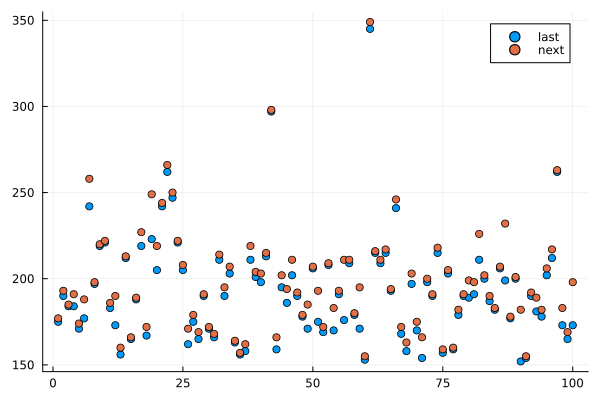

In [65]:
# Filter the DataFrame for the desired SexRatio and ReleaseTimeStep
row = filter(row -> row.SexRatio == "(5, 5)" && row.ReleaseTimeStep == 10, first_zero_df)

# Extract the Time vector (should be a Vector{Int} or Vector{Float64})
time_vec = row.Time[1]  # [1] because filter returns a DataFrame
# Filter the DataFrame for the desired SexRatio and ReleaseTimeStep
row = filter(row -> row.SexRatio == "(5, 5)" && row.ReleaseTimeStep == 10, next_zero_df)

# Extract the Time vector (should be a Vector{Int} or Vector{Float64})
time_vec_next = row.Time[1]  # [1] because filter returns a DataFrame

println(mean(time_vec))  # Calculate the mean difference between the last and next zero indices
scatter(time_vec, label="last")
scatter!(time_vec_next, label="next")

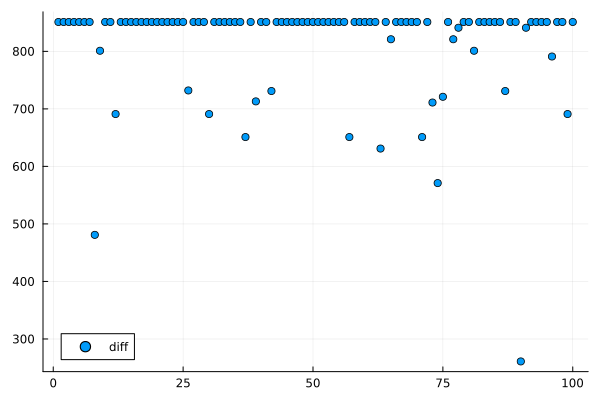

In [42]:
diff_time = [first_zero_df.Time[i] .- next_zero_df.Time[i] for i in 1:nrow(next_zero_df)]

# Create a new DataFrame with the result
diff_df = DataFrame(
    SexRatio = next_zero_df.SexRatio,
    ReleaseTimeStep = next_zero_df.ReleaseTimeStep,
    DiffTime = diff_time
)


# Filter the DataFrame for the desired SexRatio and ReleaseTimeStep
row = filter(row -> row.SexRatio == "(10, 10)" && row.ReleaseTimeStep == 10, diff_df)

# Extract the Time vector (should be a Vector{Int} or Vector{Float64})
time_vec = row.DiffTime[1]  # [1] because filter returns a DataFrame

scatter(time_vec, label="diff")